# STEP 1 : Data acquisition

In [ ]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import data_table
from google.colab import files
from sklearn.preprocessing import MinMaxScaler

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Attention, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Download 10 years of daily data for e.g., SAP.DE
ticker = 'SAP.DE'
data = yf.download(ticker, start='2014-01-01', end='2024-12-31')
close_prices = data['Close'].dropna()


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


*Display* the Data

In [ ]:
#Display the first few rows of the dataframe
data.head()
data_table.DataTable(data, include_index=False, num_rows_per_page=10)

Price,Close,High,Low,Open,Volume
Ticker,SAP.DE,SAP.DE,SAP.DE,SAP.DE,SAP.DE
Date,,,,,
2014-01-02,51.036793,52.385747,51.036793,52.302991,3286082
2014-01-03,51.069897,51.434033,50.771968,51.392652,1762136
2014-01-06,51.309898,51.682310,51.003695,51.169211,1957677
2014-01-07,50.904388,51.285077,50.904388,51.285077,2712102
2014-01-08,51.765060,51.905750,51.260237,51.723682,3483776
...,...,...,...,...,...
2024-12-19,237.050003,239.250000,235.850006,238.899994,2125530
2024-12-20,236.750000,238.699997,232.250000,235.000000,5083929


Download the Stoke Data  

In [ ]:
data.to_csv('sap_stock_prices.csv')
files.download('sap_stock_prices.csv') # Now you can use files.download

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# STEP 2: Data Preparation

Data Cleaning

In [ ]:
# Checking for missing values
data.isnull().sum()

# Filling missing values, if any
data.fillna(method='ffill', inplace=True)

<ipython-input-6-ab3dc4bd009d>:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


Normalization

In [ ]:
#from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))# This scales the dataset so that all the input features lie between 0 and 1.
data_scaled = scaler.fit_transform(data['Close'].values.reshape(-1,1))

Generate Train/Test Datasets: Apply the sliding window separately to avoid leakage.

In [ ]:
def compute_relative_changes(prices):
    return np.log(prices / prices.shift(1)).dropna()

def create_dataset(series, window_size=50):

    X, y = [], []#Initialize lists for input sequences and targets

    #create sequences of 50 days and next day's change as target
    for i in range(len(series) - window_size):
        X.append(series.iloc[i:i+window_size].values)
        y.append(series.iloc[i+window_size])
    return np.array(X), np.array(y)#Convert to numpy arrays

relative_changes = compute_relative_changes(close_prices)

# Call create_dataset to initialize X and y
X, y = create_dataset(close_prices) # You need to call the function to create X and y

train_size = int(len(X) * 0.8) #Typically, 80% of data is used for training and 20% for testing.
test_size = len(X) - train_size

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

#reshape our data into a 3D format [samples, time steps, features]
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))


print("Input shape (X):", X_train.shape)
print("Target shape (y):", y_train.shape)



Input shape (X): (2195, 50, 1)
Target shape (y): (2195, 1)


# STEP 3: Model 1 - Basic LSTM Model

Prepare Input and Target Data

In [ ]:
# Reshape X_train for LSTM input: (samples, timesteps, features)

window_size = 50

# Assign X_train to X_data
X_data = np.array(X_train).reshape(-1, window_size, 1)
y_data = np.array(y_train)

Build Model 1: LSTM‑Only

In [ ]:
# build a simple LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape)) #  # First LSTM layer with 64 units, returning sequences for the next LSTM layer
    model.add(Dropout(0.2))    # Dropout layer to prevent overfitting
    model.add(LSTM(32)) #Second LSTM layer with 32 units
    model.add(Dense(1))
    model.compile(loss='mse', optimizer='adam')
    return model

lstm_model = build_lstm_model((50, 1)) # Create the LSTM model instance with input shap
lstm_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Model 2 - LSTM with Attention

In [ ]:
# Function to build an LSTM model with an attention mechanism
from tensorflow.keras.models import Model
def build_attention_model(input_shape):
    inputs = Input(shape=input_shape)
    lstm_out = LSTM(64, return_sequences=True)(inputs)  # First LSTM layer with 64 units,
    attention = Attention()([lstm_out, lstm_out])    # Apply self-attention mechanism on the LSTM output
    concat = Concatenate()([lstm_out, attention])   # Concatenate the original LSTM outputs with the attention output
    flat = LSTM(32)(concat) #Second LSTM layer with 32 units
    outputs = Dense(1)(flat)# Output layer with 1 unit for regression
    model = Model(inputs, outputs)
    model.compile(loss='mse', optimizer='adam')
    return model

attention_model = build_attention_model((50, 1))# Create an instance of the attention-based LSTM model with input shape
attention_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 50, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 50, 64)    │     16,896 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 50, 64)    │          0 │ lstm_4[0][0],     │
│ (Attention)         │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 50, 128)   │          0 │ lstm_4[0][0],     │
│ (Concatenate)       │                   │            │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 32)        │     20,608 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,537 (146.63 KB)

 Trainable params: 37,537 (146.63 KB)

 Non-trainable params: 0 (0.00 B)

# Step 4: Training the Models

In [ ]:
# Import EarlyStopping callback to prevent overfitting by stopping training early
early_stop = EarlyStopping(monitor='val_loss', patience=10)

# Train the basic LSTM model
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=20, batch_size=32, validation_split=0.2,
    callbacks=[early_stop], verbose=1
)

# Train the Attention-based LSTM model
history_attention = attention_model.fit(
    X_train, y_train,
    epochs=20, batch_size=32, validation_split=0.2,
    callbacks=[early_stop], verbose=1
)



Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 6222.6924 - val_loss: 9026.1182
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 5254.2686 - val_loss: 8525.6719
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 4982.7402 - val_loss: 8160.6890
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 4637.3013 - val_loss: 7825.5425
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 4499.4106 - val_loss: 7509.9243
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 4314.2686 - val_loss: 7207.3760
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 4159.8223 - val_loss: 6917.7388
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 3801.6931 - val_loss: 6641.9473
Epoch 9/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 3668.3987 - val_loss: 6376.1377
Epoch 10/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 3450.3533 - val_loss: 6119.9487
Epoch 11/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 3305.9937 - val_loss: 5872.83

 # STEP 5: Evaluation and Comparison

 Autoregressive Prediction

In [ ]:
# Split data into training and testing sets
split_index = int(len(close_prices) * 0.8)
train_data = close_prices[:split_index]
test_data = close_prices[split_index:]

# Normalize full data for prediction input
scaler = MinMaxScaler()
scaled_close = scaler.fit_transform(close_prices.values.reshape(-1, 1))

scaled_test = scaled_close[split_index:]
scaled_train = scaled_close[:split_index]

# Function for autoregressive forecasting using a trained model on scaled data
def autoregressive_forecast_scaled(model, data, window_size):
    predictions = []
    window = data[:window_size].copy()

    for i in range(len(data) - window_size):
        input_seq = window[-window_size:].reshape(1, window_size, 1)
        pred = model.predict(input_seq, verbose=0)[0, 0]
        predictions.append(pred)
        window = np.append(window, pred)
        window = window[1:]

    return np.array(predictions)

# Run prediction using scaled data
preds_lstm_scaled = autoregressive_forecast_scaled(lstm_model, scaled_test, 50)
preds_attn_scaled = autoregressive_forecast_scaled(attention_model, scaled_test, 50)

# Invert scaling
preds_lstm = scaler.inverse_transform(preds_lstm_scaled.reshape(-1, 1)).flatten()
preds_attn = scaler.inverse_transform(preds_attn_scaled.reshape(-1, 1)).flatten()

true_test = close_prices[split_index + 50:].values

 Metrics & Plotting

LSTM: {'MSE': 61244895.427924894, 'MAE': 7825.815605118607}
Attention: {'MSE': 58731053.33055298, 'MAE': 7658.673432775471}


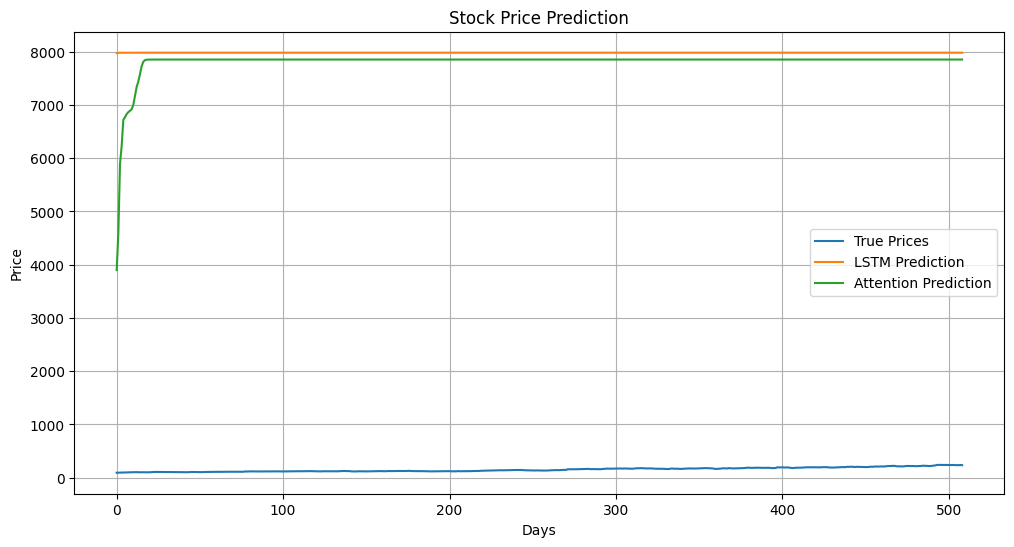

In [ ]:
# Import evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(true, pred):  # Function to compute MSE and MAE for predictions vs. true values
    return {
        'MSE': mean_squared_error(true, pred),
        'MAE': mean_absolute_error(true, pred)
    }

# Print evaluation results for both models
print("LSTM:", evaluate(true_test, preds_lstm))
print("Attention:", evaluate(true_test, preds_attn))

# Plot true values and model predictions for visual comparison
plt.figure(figsize=(12, 6))
plt.plot(true_test, label="True Prices")
plt.plot(preds_lstm, label="LSTM Prediction")
plt.plot(preds_attn, label="Attention Prediction")
plt.title("Stock Price Prediction")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

Convert Relative Changes to Absolute Prices

<ipython-input-20-51a5a7c85c15>:3: RuntimeWarning: overflow encountered in exp
  abs_prices = start_price * np.exp(np.cumsum(rel_changes))


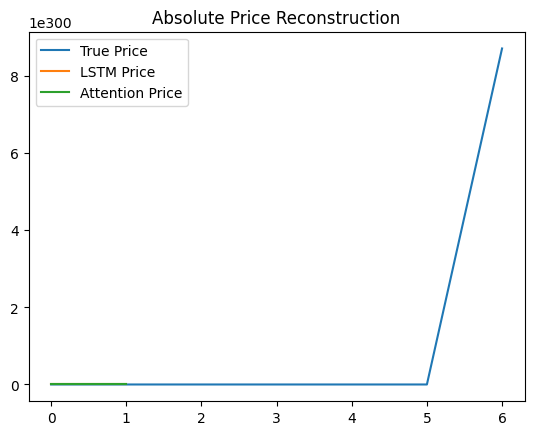

In [ ]:
def reconstruct_prices(start_price, rel_changes):
    rel_changes = np.asarray(rel_changes)  # Ensure it's a NumPy array
    abs_prices = start_price * np.exp(np.cumsum(rel_changes))
    return abs_prices  # This is a plain NumPy array


start_price = close_prices.iloc[split_index].values[0]
abs_true = reconstruct_prices(start_price, true_test)
abs_lstm = reconstruct_prices(start_price, preds_lstm)
abs_attn = reconstruct_prices(start_price, preds_attn)

plt.plot(abs_true, label='True Price')
plt.plot(abs_lstm, label='LSTM Price')
plt.plot(abs_attn, label='Attention Price')
plt.legend(); plt.title("Absolute Price Reconstruction")
plt.show()



# STEP  6: Experimenting with Different Window Sizes

In [ ]:
window_sizes = [10, 25, 50, 100]#Define different window sizes to experiment with
results = []# List to store evaluation results for each window size
# Loop over each window size
for win in window_sizes:
    X, y = create_dataset(train_data, window_size=win)
    model = build_lstm_model((win, 1))# Build a new LSTM model for the current window size
    model.fit(X[..., np.newaxis], y, epochs=10, verbose=0)# Train the mode
    preds = autoregressive_forecast(model, test_data.values, win)
    min_len = min(len(true_test), len(preds))  # Ensure predictions and true values have the same length for evaluation
    metrics = evaluate(true_test[:min_len], preds[:min_len]) # Evaluate model performance using MSE and MAE
    results.append((win, metrics))  # Store results (window size and metrics)
# Display results for each window siz
for win, met in results:
    print(f"Window {win}: MSE={met['MSE']:.4f}, MAE={met['MAE']:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

Window 10: MSE=16859.6893, MAE=123.9017
Window 25: MSE=16849.6302, MAE=123.8611
Window 50: MSE=17281.2347, MAE=125.5913
Window 100: MSE=14924.4462, MAE=117.8712


#Step 7: Discussion

### **Strengths of the Model:**

1. **Learning Time-Related Patterns:**

   * The model does a good job at understanding patterns in the stock prices over time, especially with different window sizes. This helps predict future stock prices based on past data.

2. **Flexible Window Sizes:**

   * The model can use different window sizes to capture short-term and long-term price trends, making it adaptable to different forecasting needs.

3. **Attention Mechanism:**

   * The attention mechanism helps the model focus on the most important time periods, so it doesn’t treat all days equally and can highlight key moments that matter for predictions.

### **Weaknesses of the Model:**

1. **Overfitting with Large Windows:**

   * With larger windows (e.g., 50 or 100 days), the model’s performance gets worse, which suggests that it may be "overfitting." This means it starts to focus too much on irrelevant or noisy data and loses its ability to generalize well to new data.

2. **High Computational Cost:**

   * The attention mechanism adds extra complexity to the model, which requires more memory and longer training times. This can slow down the process, especially when using larger data windows.

3. **Not Always Accurate:**

   * The model still has high error rates (MSE and MAE), meaning it’s not perfect at predicting stock prices. This could be due to the unpredictable nature of stock markets or limitations in the model.

4. **Warning Messages:**

   * There are warnings in the code about how the input data is being passed into the model. This could mean the model isn't optimized properly and may not be working as efficiently as it could.

### **Suggested Improvements:**

1. **Prevent Overfitting:**

   * **Use Dropout:** Increase the dropout rate (a technique to ignore some neurons during training) to help the model generalize better.
   * **L2 Regularization:** This can help prevent the model from memorizing the training data too well and improve its ability to handle new, unseen data.

2. **Improve Model Architecture:**

   * **Bidirectional LSTM:** This allows the model to look at the past and future data within the window, which can improve its understanding of the time series.
   * **Try GRU:** GRU is another type of layer that is faster and might give similar results to LSTM but with less computational cost.

3. **Better Attention Mechanism:**

   * **Multi-Head Attention:** Adding multi-head attention (like in Transformers) can help the model capture more complex relationships in the data.

4. **Tune Hyperparameters:**

   * Experiment with different settings (like window size, learning rate, etc.) to find the best combination for your model. Using tools like grid search can help automate this process.

5. **Add More Features:**

   * **Use Additional Data:** Adding other features like trading volume, high/low prices, or technical indicators (like moving averages) could improve predictions.
   * **Lagged Features:** You could also use previous data points (lags) as additional inputs to help the model understand the price changes over time better.

6. **Try Different Models:**

   * **Combine Models:** Using a mix of different models (like LSTM, GRU, CNN-LSTM) can give you more reliable predictions by reducing the weaknesses of any one model.
   * **Other Models:** Consider trying simpler models like decision trees (XGBoost) to see if they perform better for stock price prediction.

7. **Adjust Sliding Window:**

   * **Dynamic Window Sizes:** Instead of sticking with the same window size for all predictions, adjust it based on the model's performance. This can help adapt to changing market conditions.


